In [1]:
# 주피터 노트북 내에서 직접 설치하는 명령어입니다.
!pip install openpyxl scipy

In [2]:
import os
import pandas as pd

# 1. 일단 Downloads 폴더를 기준으로 탐색합니다.
base_path = r'C:\Downloads'

# 2. 'Anonymized_Data_Identifiers.xlsx' 파일이 어디 있는지 직접 찾기
target_file = 'Anonymized_Data_Identifiers.xlsx'
found_path = ""

for root, dirs, files in os.walk(base_path):
    if target_file in files:
        found_path = os.path.join(root, target_file)
        break

# 3. 찾은 경로로 데이터 로드 시도
if found_path:
    print(f"✅ 파일을 찾았습니다: {found_path}")
    df_info = pd.read_excel(found_path)
    display(df_info.head())
    print("\n컬럼 목록:", df_info.columns.tolist())
else:
    print("❌ 파일을 찾지 못했습니다. 파일명이 정확한지, 혹은 다운로드 폴더에 있는지 확인해주세요.")

✅ 파일을 찾았습니다: C:\Downloads\knee_data\Data for Surface EMG muscle activation patterns of the lower extremities during gait in individuals with and without a knee injury history\Anonymized_Data_Identifiers.xlsx


,"Side (1-Right, 2-Left)",Subject ID,"Leg (for injured group: 0-Contralateral leg, 1-Injured leg; for control group: 0-Dominant leg, 1-Non-dominant leg)",Knee Injury History,"Sex (0-Female, 1-Male)",Age at testing [years],Time since injury [months],Height [cm],Weight [kg],Contralateral Knee Injury
0,1,12,0,1,1,30,144.5,168.8,69.0,1
1,2,12,1,1,1,30,144.5,168.8,69.0,1
2,1,99,1,1,0,26,117.0,167.2,61.2,1
3,2,99,0,1,0,26,117.0,167.2,61.2,1
4,1,112,0,1,0,27,93.6,170.0,58.7,0



컬럼 목록: ['Side (1-Right, 2-Left)', 'Subject ID', 'Leg (for injured group: 0-Contralateral leg, 1-Injured leg; for control group: 0-Dominant leg, 1-Non-dominant leg)', 'Knee Injury History', 'Sex (0-Female, 1-Male)', 'Age at testing [years]', 'Time since injury [months]', 'Height [cm]', 'Weight [kg]', 'Contralateral Knee Injury']


In [3]:
import os
import scipy.io

# 1. 탐색 시작 지점 설정 (Downloads 폴더)
base_path = r'C:\Downloads'
target_file = 'M.mat'
found_m_path = ""

# 2. 파일 위치 직접 찾기
for root, dirs, files in os.walk(base_path):
    if target_file in files:
        found_m_path = os.path.join(root, target_file)
        break

# 3. 파일을 찾았다면 로드하기
if found_m_path:
    print(f"✅ 파일을 찾았습니다: {found_m_path}")
    m_data = scipy.io.loadmat(found_m_path)
    
    # 내부 데이터 목록 확인
    m_keys = [k for k in m_data.keys() if "__" not in k]
    print(f"✅ 로드 성공! 들어있는 항목: {m_keys}")
else:
    print("❌ 파일을 찾지 못했습니다. 'knee_data' 폴더 안에 'M.mat'이 있는지 확인해주세요!")

✅ 파일을 찾았습니다: C:\Downloads\knee_data\Data for Surface EMG muscle activation patterns of the lower extremities during gait in individuals with and without a knee injury history\M.mat
✅ 로드 성공! 들어있는 항목: ['M']


In [4]:
# M_array 불러오기

M_array = m_data['M']

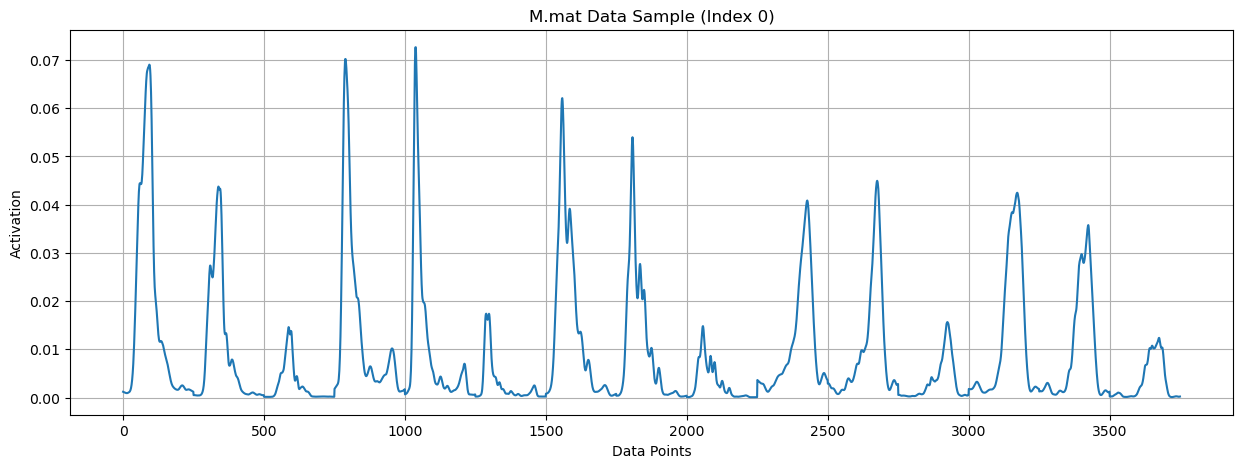

한 줄당 데이터 포인트 수: 3750


In [5]:
import matplotlib.pyplot as plt

# 1. 2차원이니까 [행 번호, 열 번호] 형식으로 접근해야 합니다.
plt.figure(figsize=(15, 5))

# 첫 번째 데이터(0번 행)의 처음부터 끝까지 그리기
plt.plot(M_array[0, :]) 

plt.title("M.mat Data Sample (Index 0)")
plt.xlabel("Data Points")
plt.ylabel("Activation")
plt.grid(True)
plt.show()

# 데이터가 어떻게 구성됐는지 추측하기 위해 샘플 개수 확인
print(f"한 줄당 데이터 포인트 수: {M_array.shape[1]}")

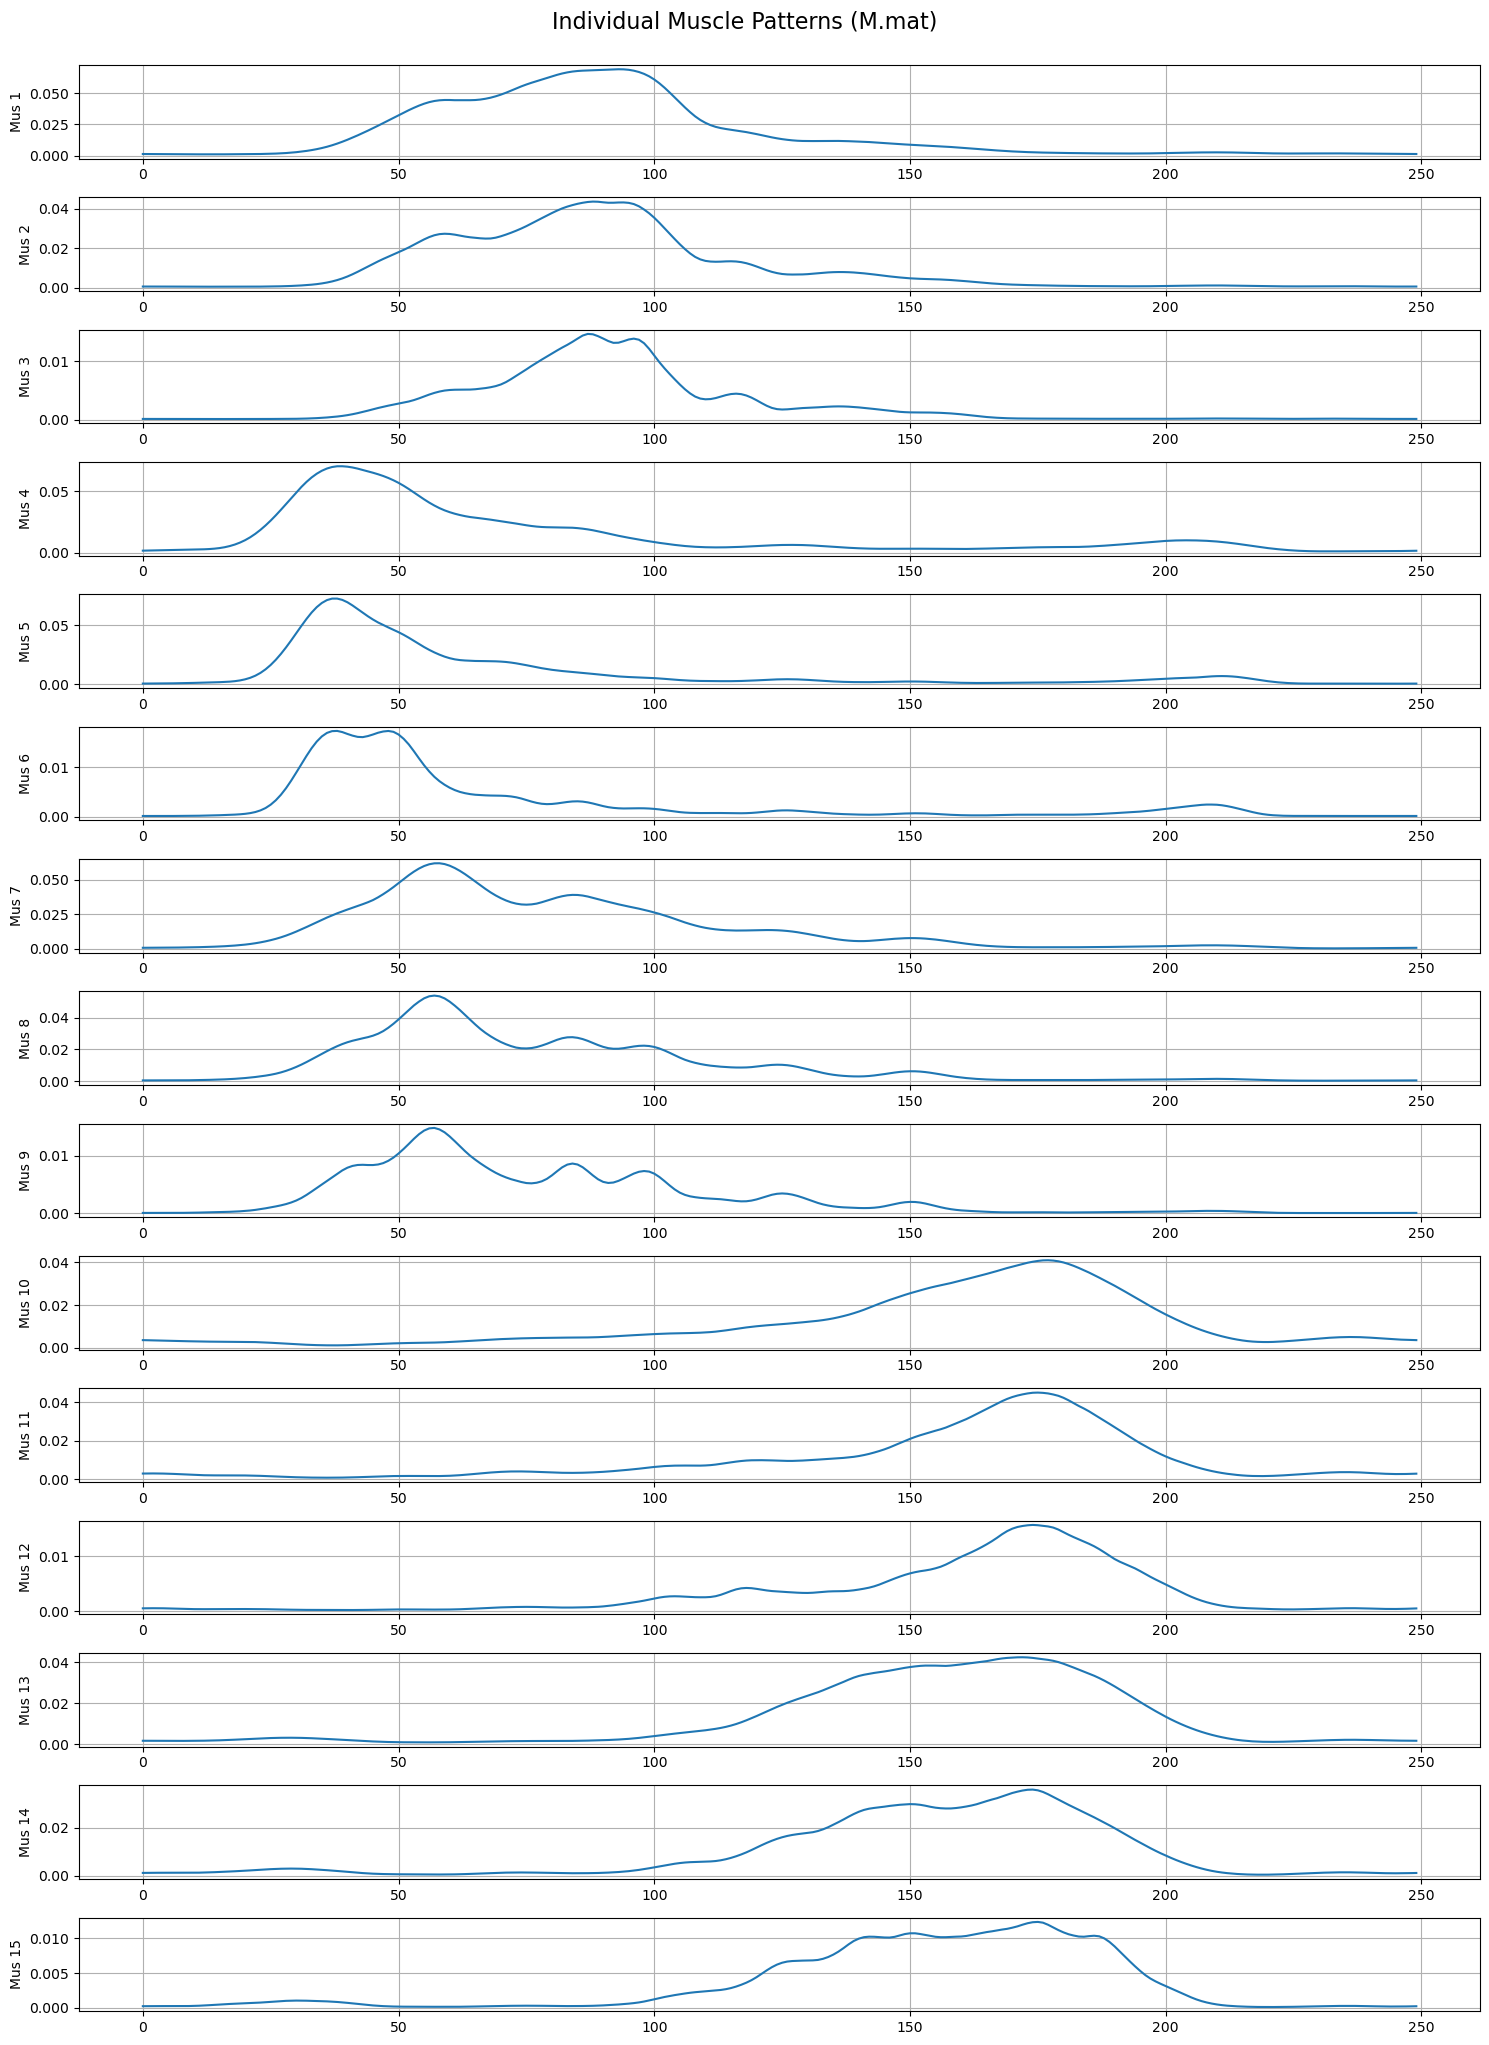

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터를 근육별로 자르기 (3750을 15개 또는 16개로 나눈다고 가정)
# 여기서는 시각적으로 확인하기 위해 250포인트씩 15개 구간으로 나눠서 그려볼게요.
sample_data = M_array[0] # 첫 번째 피험자
segment_size = 250       # 한 근육당 포인트 (예상)
num_muscles = 15         # 총 구간 개수

plt.figure(figsize=(15, 20))

for i in range(num_muscles):
    start = i * segment_size
    end = (i + 1) * segment_size
    
    plt.subplot(num_muscles, 1, i + 1)
    plt.plot(sample_data[start:end])
    plt.ylabel(f'Mus {i+1}')
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Individual Muscle Patterns (M.mat)", y=1.02, fontsize=16)
plt.show()

In [7]:
# 0과 1이 각각 몇 명인지 카운트
print("--- 그룹별 인원수 확인 ---")
print(df_info['Knee Injury History'].value_counts())

--- 그룹별 인원수 확인 ---
Knee Injury History
0    66
1    56
Name: count, dtype: int64


In [8]:
import pandas as pd
import numpy as np

# 1. 근육 이름 (8개)
muscle_names = ['VL', 'VM', 'RF', 'BF', 'ST', 'MG', 'LG', 'TA']

# 2. 개별 피험자별 데이터를 담을 리스트
individual_data = []

for idx in range(len(M_array)): # 122명 전체 반복
    row = {
        'Subject_Index': idx,
        'Injury_History': df_info.iloc[idx]['Knee Injury History'], # 0:정상, 1:부상
        'Age': df_info.iloc[idx]['Age at testing [years]'],
        'Sex': df_info.iloc[idx]['Sex (0-Female, 1-Male)']
    }
    
    # 각 근육별로 평균값 계산해서 추가
    for i, m_name in enumerate(muscle_names):
        start = i * 250
        end = (i + 1) * 250
        muscle_mean = np.mean(M_array[idx, start:end])
        row[f'{m_name}_Mean'] = round(muscle_mean, 4)
        
    individual_data.append(row)

# 3. 데이터프레임 생성
df_individual = pd.DataFrame(individual_data)

# 4. 결과 확인 (상위 10명만)
print("✅ 피험자별 근육 평균 데이터 생성 완료!")
display(df_individual.head(10))

# 5. [중요] 엑셀 파일로 저장하기 (이걸 해야 나중에 편해요!)
df_individual.to_excel('Individual_Muscle_Analysis.xlsx', index=False)
print("\n💾 'Individual_Muscle_Analysis.xlsx' 파일로 저장되었습니다!")

✅ 피험자별 근육 평균 데이터 생성 완료!


,Subject_Index,Injury_History,Age,Sex,VL_Mean,VM_Mean,RF_Mean,BF_Mean,ST_Mean,MG_Mean,LG_Mean,TA_Mean
0,0,1.0,30.0,1.0,0.0174,0.0100,0.0027,0.0145,0.0107,0.0028,0.0143,0.0104
1,1,1.0,30.0,1.0,0.0173,0.0109,0.0031,0.0175,0.0125,0.0027,0.0146,0.0107
2,2,1.0,26.0,0.0,0.0148,0.0075,0.0024,0.0172,0.0089,0.0018,0.0136,0.0096
3,3,1.0,26.0,0.0,0.0173,0.0089,0.0028,0.0171,0.0104,0.0025,0.0133,0.0106
4,4,1.0,27.0,0.0,0.0157,0.0098,0.0028,0.0202,0.0103,0.0022,0.0146,0.0105
5,5,1.0,27.0,0.0,0.0189,0.0105,0.0027,0.0168,0.0107,0.0028,0.0147,0.0101
6,6,0.0,24.0,1.0,0.0161,0.0112,0.0027,0.0189,0.0102,0.0026,0.0151,0.0101
7,7,0.0,24.0,1.0,0.0140,0.0096,0.0024,0.0180,0.0100,0.0018,0.0126,0.0093
8,8,1.0,26.0,1.0,0.0194,0.0102,0.0038,0.0182,0.0118,0.0036,0.0181,0.0111
9,9,1.0,26.0,1.0,0.0190,0.0113,0.0033,0.0180,0.0113,0.0034,0.0146,0.0108



💾 'Individual_Muscle_Analysis.xlsx' 파일로 저장되었습니다!


C:\Users\smhrd1\AppData\Local\Temp\ipykernel_6268\3079646249.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Injury_History', y='VL_Mean', data=df_individual, palette='Set2')
C:\Users\smhrd1\AppData\Local\Temp\ipykernel_6268\3079646249.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Injury_History', y='VM_Mean', data=df_individual, palette='Set2')


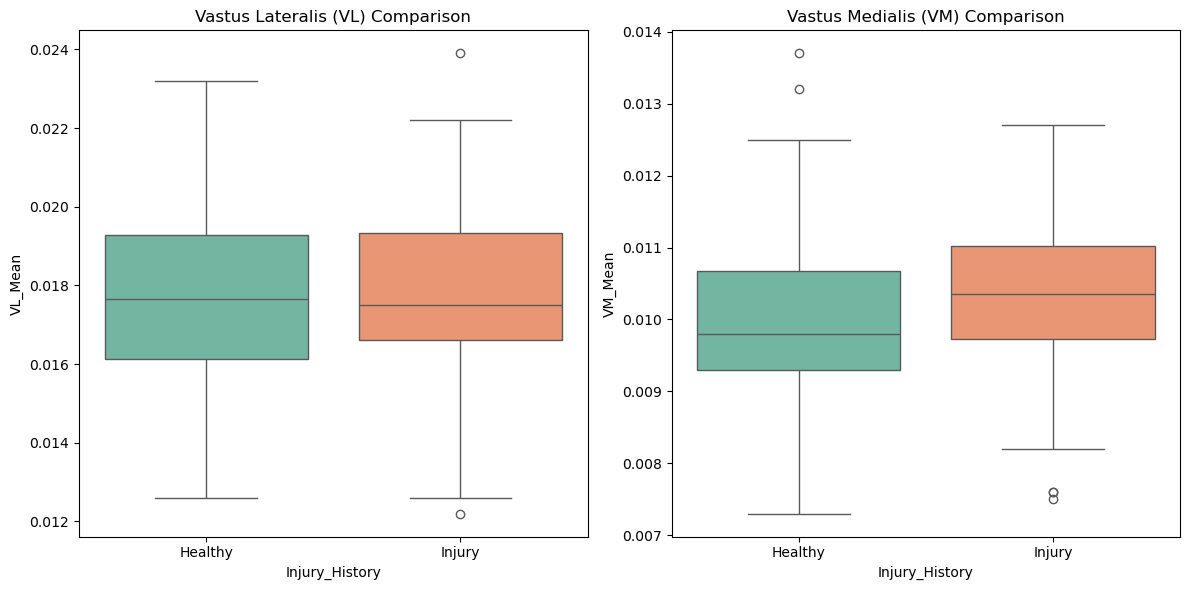

--- 그룹별 평균 비교 ---
                 VL_Mean   VM_Mean
Injury_History                    
0.0             0.017586  0.010017
1.0             0.017852  0.010212


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 그래프를 그리기 위해 데이터 정리
plt.figure(figsize=(12, 6))

# 1. Vastus Lateralis (VL) 비교
plt.subplot(1, 2, 1)
sns.boxplot(x='Injury_History', y='VL_Mean', data=df_individual, palette='Set2')
plt.title('Vastus Lateralis (VL) Comparison')
plt.xticks([0, 1], ['Healthy', 'Injury'])

# 2. Vastus Medialis (VM) 비교
plt.subplot(1, 2, 2)
sns.boxplot(x='Injury_History', y='VM_Mean', data=df_individual, palette='Set2')
plt.title('Vastus Medialis (VM) Comparison')
plt.xticks([0, 1], ['Healthy', 'Injury'])

plt.tight_layout()
plt.show()

# 실제 평균값 차이 출력
means = df_individual.groupby('Injury_History')[['VL_Mean', 'VM_Mean']].mean()
print("--- 그룹별 평균 비교 ---")
print(means)

C:\Users\smhrd1\AppData\Local\Temp\ipykernel_6268\2597941168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Injury_History', y='VM_VL_Ratio', data=df_individual, palette='coolwarm')


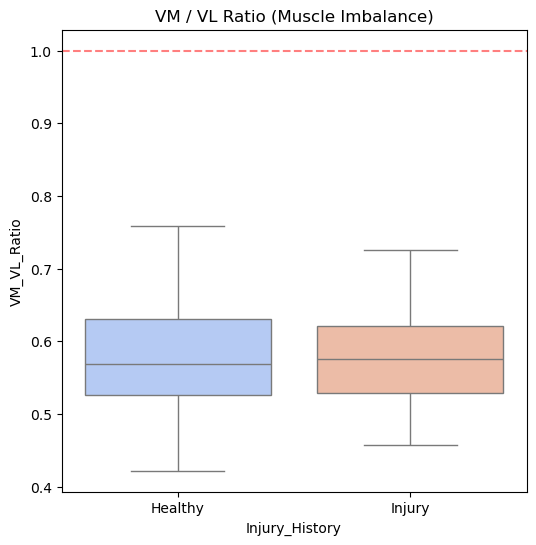

Injury_History
0.0    0.575233
1.0    0.576582
Name: VM_VL_Ratio, dtype: float64


In [10]:
# 1. VM/VL 비율 계산 (불균형 지표)
df_individual['VM_VL_Ratio'] = df_individual['VM_Mean'] / df_individual['VL_Mean']

# 2. 비율로 다시 비교하기
plt.figure(figsize=(6, 6))
sns.boxplot(x='Injury_History', y='VM_VL_Ratio', data=df_individual, palette='coolwarm')
plt.title('VM / VL Ratio (Muscle Imbalance)')
plt.xticks([0, 1], ['Healthy', 'Injury'])
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5) # 1.0이면 똑같이 쓰는 것
plt.show()

print(df_individual.groupby('Injury_History')['VM_VL_Ratio'].mean())

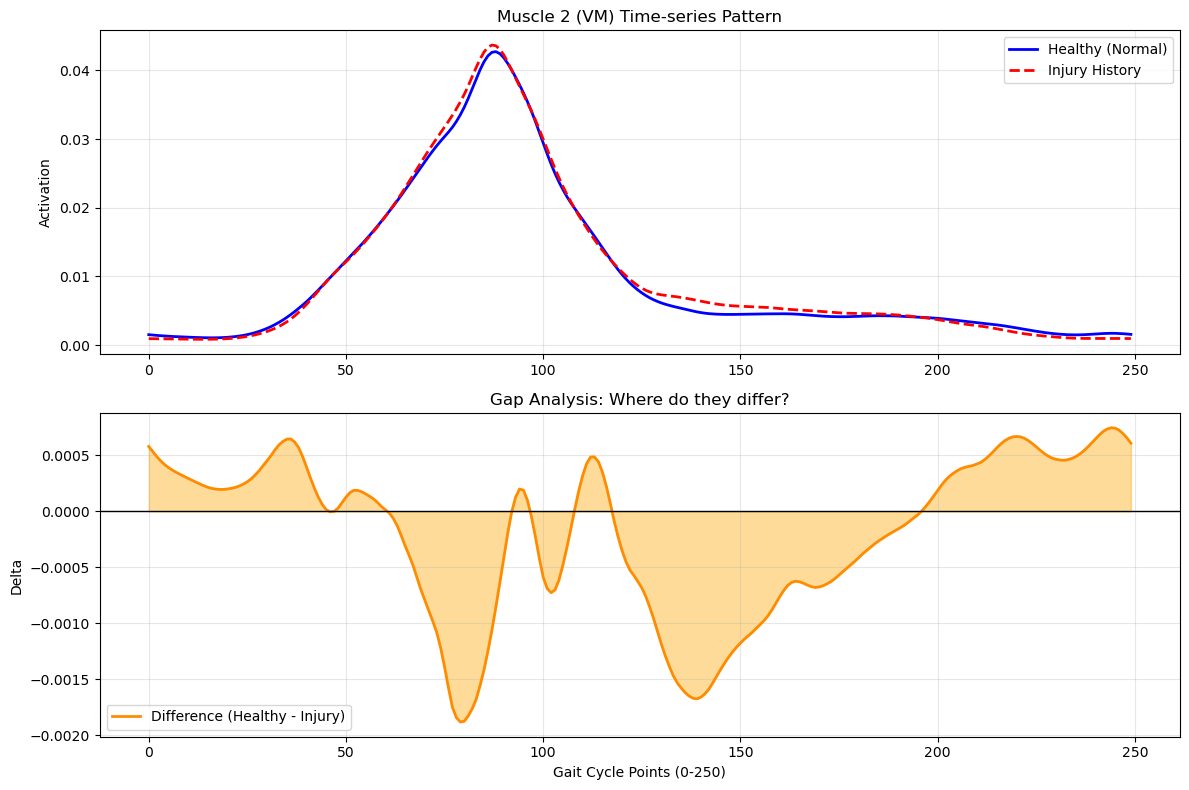

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 그룹 인덱스 다시 정의 (에러 방지)
group_labels = df_info['Knee Injury History'].values[:122]
normal_idx = np.where(group_labels == 0)[0]
injury_idx = np.where(group_labels == 1)[0]

# 2. 분석할 근육 선택 (2번 VM - 내측광근)
m_idx = 1 # 0:VL, 1:VM
start, end = m_idx * 250, (m_idx + 1) * 250

# 3. 데이터 추출 및 평균 계산
vm_all = M_array[:, start:end]
vm_healthy_mean = np.mean(vm_all[normal_idx], axis=0)
vm_injury_mean = np.mean(vm_all[injury_idx], axis=0)

# 4. 차이(Difference) 계산
diff = vm_healthy_mean - vm_injury_mean

# 5. 시각화
plt.figure(figsize=(12, 8))

# 상단: 두 그룹의 평균 파형 비교 (Heel Strike 시점 확인용)
plt.subplot(2, 1, 1)
plt.plot(vm_healthy_mean, label='Healthy (Normal)', color='blue', linewidth=2)
plt.plot(vm_injury_mean, label='Injury History', color='red', linewidth=2, linestyle='--')
plt.title(f'Muscle {m_idx+1} (VM) Time-series Pattern')
plt.ylabel('Activation')
plt.legend()
plt.grid(True, alpha=0.3)

# 하단: 두 그룹의 차이값 (가장 벌어지는 '골든 구간' 찾기)
plt.subplot(2, 1, 2)
plt.fill_between(range(250), diff, color='orange', alpha=0.4)
plt.plot(diff, color='darkorange', label='Difference (Healthy - Injury)', linewidth=2)
plt.axhline(0, color='black', lw=1)
plt.title('Gap Analysis: Where do they differ?')
plt.xlabel('Gait Cycle Points (0-250)')
plt.ylabel('Delta')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#분석 결과: "무릎 부상자는 더 처절하게 버티고 있다"
#75~85 포인트 구간 (가장 깊은 골):

#이 시점은 보통 발이 지면에 완전히 닿고 체중을 지지하는 Mid-stance(중간 입각기) 직전일 가능성
#정상인은 효율적으로 힘을 빼고 걷는 구간인데, 부상자는 무릎의 불안정성 때문에 내측광근(VM)을 억지로 더 꽉 쥐고
#(Over-activation) 버티고 있는 거예요. "안 아프려고, 안 흔들리려고" 근육을 과하게 쓰고 있다는 증거입니다.
#130~150 포인트 구간
#가락이 땅에서 떨어지기 시작하는 Terminal Stance ~ Pre-swing 구간입니다.
#이때도 부상군의 활성도가 더 높습니다. 추진력을 내야 할 때 효율적으로 근육을 쓰지 못하고, 
#무릎 관절을 보호하기 위해 불필요한 긴장(Guard mechanism)을 유지하고 있다고 볼 수 있습니다.

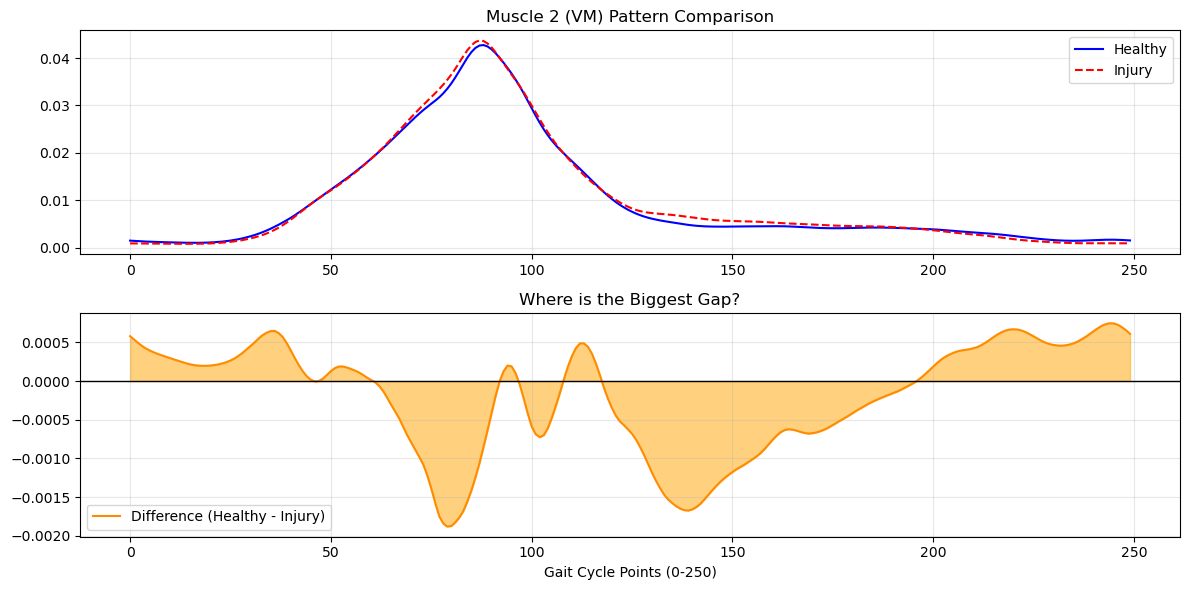

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 분석할 근육 선택 (가장 의심되는 2번 VM - 내측광근)
m_idx = 1 # 0:VL, 1:VM
start, end = m_idx * 250, (m_idx + 1) * 250

# 2. 모든 피험자의 해당 근육 데이터 추출
vm_all = M_array[:, start:end]

# 3. 그룹별 평균 파형 계산
vm_healthy_mean = np.mean(vm_all[normal_idx], axis=0)
vm_injury_mean = np.mean(vm_all[injury_idx], axis=0)

# 4. 차이(Difference) 계산
diff = vm_healthy_mean - vm_injury_mean

# 5. 시각화
plt.figure(figsize=(12, 6))

# 상단: 두 그룹의 평균 파형 비교
plt.subplot(2, 1, 1)
plt.plot(vm_healthy_mean, label='Healthy', color='blue')
plt.plot(vm_injury_mean, label='Injury', color='red', linestyle='--')
plt.title(f'Muscle {m_idx+1} (VM) Pattern Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# 하단: 두 그룹의 차이값 (어느 구간에서 가장 많이 벌어지는가?)
plt.subplot(2, 1, 2)
plt.fill_between(range(250), diff, color='orange', alpha=0.5)
plt.plot(diff, color='darkorange', label='Difference (Healthy - Injury)')
plt.axhline(0, color='black', lw=1)
plt.title('Where is the Biggest Gap?')
plt.xlabel('Gait Cycle Points (0-250)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
df_individual

,Subject_Index,Injury_History,Age,Sex,VL_Mean,VM_Mean,RF_Mean,BF_Mean,ST_Mean,MG_Mean,LG_Mean,TA_Mean,VM_VL_Ratio
0,0,1.0,30.0,1.0,0.0174,0.0100,0.0027,0.0145,0.0107,0.0028,0.0143,0.0104,0.574713
1,1,1.0,30.0,1.0,0.0173,0.0109,0.0031,0.0175,0.0125,0.0027,0.0146,0.0107,0.630058
2,2,1.0,26.0,0.0,0.0148,0.0075,0.0024,0.0172,0.0089,0.0018,0.0136,0.0096,0.506757
3,3,1.0,26.0,0.0,0.0173,0.0089,0.0028,0.0171,0.0104,0.0025,0.0133,0.0106,0.514451
4,4,1.0,27.0,0.0,0.0157,0.0098,0.0028,0.0202,0.0103,0.0022,0.0146,0.0105,0.624204
...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,117,0.0,18.0,1.0,0.0181,0.0117,0.0028,0.0174,0.0119,0.0029,0.0126,0.0096,0.646409
118,118,1.0,19.0,1.0,0.0171,0.0110,0.0016,0.0187,0.0100,0.0017,0.0127,0.0091,0.643275
119,119,1.0,19.0,1.0,0.0170,0.0110,0.0016,0.0182,0.0099,0.0017,0.0147,0.0096,0.647059
120,120,0.0,23.0,1.0,0.0212,0.0125,0.0025,0.0173,0.0116,0.0031,0.0145,0.0106,0.589623


In [19]:
df_individual

,Subject_Index,Injury_History,Age,Sex,VL_Mean,VM_Mean,RF_Mean,BF_Mean,ST_Mean,MG_Mean,LG_Mean,TA_Mean,VM_VL_Ratio,VM_at_80
0,0,1.0,30.0,1.0,0.0174,0.0100,0.0027,0.0145,0.0107,0.0028,0.0143,0.0104,0.574713,0.037942
1,1,1.0,30.0,1.0,0.0173,0.0109,0.0031,0.0175,0.0125,0.0027,0.0146,0.0107,0.630058,0.053714
2,2,1.0,26.0,0.0,0.0148,0.0075,0.0024,0.0172,0.0089,0.0018,0.0136,0.0096,0.506757,0.026152
3,3,1.0,26.0,0.0,0.0173,0.0089,0.0028,0.0171,0.0104,0.0025,0.0133,0.0106,0.514451,0.027840
4,4,1.0,27.0,0.0,0.0157,0.0098,0.0028,0.0202,0.0103,0.0022,0.0146,0.0105,0.624204,0.039857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,117,0.0,18.0,1.0,0.0181,0.0117,0.0028,0.0174,0.0119,0.0029,0.0126,0.0096,0.646409,0.043378
118,118,1.0,19.0,1.0,0.0171,0.0110,0.0016,0.0187,0.0100,0.0017,0.0127,0.0091,0.643275,0.032077
119,119,1.0,19.0,1.0,0.0170,0.0110,0.0016,0.0182,0.0099,0.0017,0.0147,0.0096,0.647059,0.052564
120,120,0.0,23.0,1.0,0.0212,0.0125,0.0025,0.0173,0.0116,0.0031,0.0145,0.0106,0.589623,0.033372


In [18]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd

# # 1. 'VM_at_80' 데이터 다시 생성해서 df_individual에 확실히 넣기
# target_point = 80
# m_idx = 1  # VM (내측광근)
# df_individual['VM_at_80'] = M_array[:, m_idx * 250 + target_point]

# # 2. 분석에 사용할 컬럼들 이름 정확히 맞추기 (보내주신 스크린샷 기준)
# # 이름이 긴 컬럼들은 분석하기 편하게 리스트로 담습니다.
# cols_for_corr = [
#     'Knee Injury History', 
#     'Age at testing [years]', 
#     'Sex (0-Female, 1-Male)', 
#     'Height [cm]', 
#     'Weight [kg]', 
#     'VM_at_80',    # 우리가 만든 80포인트 값
#     'VM_Mean'      # 전체 평균값
# ]

# # 3. 상관관계 계산 (df_individual에 위 정보들이 다 들어있어야 합니다)
# # 만약 df_individual에 키/몸무게가 없다면 df_info에서 가져와야 함
# corr_data = df_individual[cols_for_corr].corr()

# # 4. 히트맵 그리기
# plt.figure(figsize=(12, 10))
# sns.heatmap(corr_data, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
# plt.title("Correlation: Injury, Body Info, and Muscle Activity", fontsize=15)
# plt.show()

KeyError: "['Knee Injury History', 'Age at testing [years]', 'Sex (0-Female, 1-Male)', 'Height [cm]', 'Weight [kg]'] not in index"

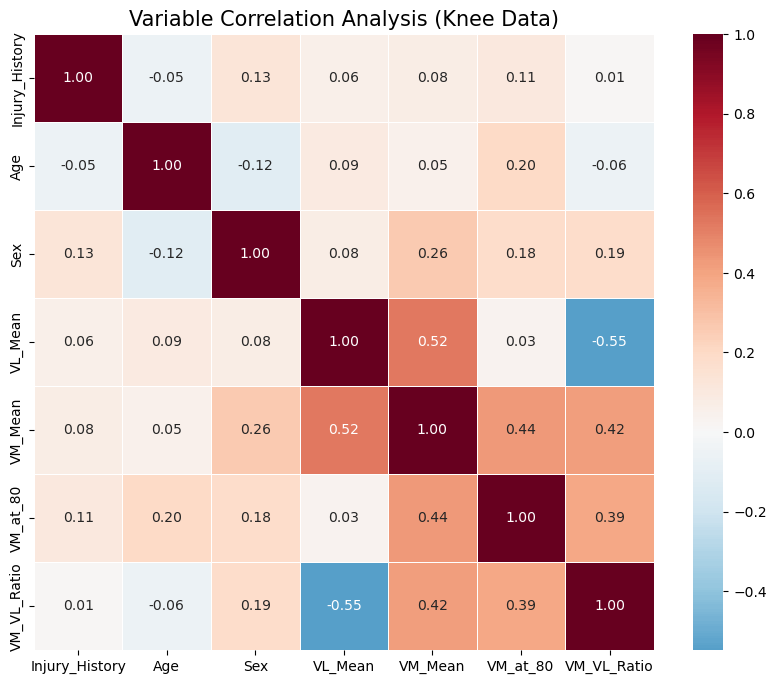

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관관계 분석할 핵심 변수들만 추리기
# (현경님의 df_individual에 있는 컬럼명에 맞춰 조절하세요)
analysis_cols = ['Injury_History', 'Age', 'Sex', 'VL_Mean', 'VM_Mean', 'VM_at_80', 'VM_VL_Ratio']

# 2. 상관계수 계산
corr_matrix = df_individual[analysis_cols].corr()

# 3. 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Variable Correlation Analysis (Knee Data)', fontsize=15)
plt.show()

In [23]:
df_final

,"Side (1-Right, 2-Left)",Subject ID,"Leg (for injured group: 0-Contralateral leg, 1-Injured leg; for control group: 0-Dominant leg, 1-Non-dominant leg)",Knee Injury History,"Sex (0-Female, 1-Male)",Age at testing [years],Time since injury [months],Height [cm],Weight [kg],Contralateral Knee Injury,VM_at_80,VM_Mean,VL_Mean,VM_VL_Ratio
0,1,12,0,1,1,30,144.5,168.8,69.0,1,0.037942,0.0100,0.0174,0.574713
1,2,12,1,1,1,30,144.5,168.8,69.0,1,0.053714,0.0109,0.0173,0.630058
2,1,99,1,1,0,26,117.0,167.2,61.2,1,0.026152,0.0075,0.0148,0.506757
3,2,99,0,1,0,26,117.0,167.2,61.2,1,0.027840,0.0089,0.0173,0.514451
4,1,112,0,1,0,27,93.6,170.0,58.7,0,0.039857,0.0098,0.0157,0.624204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2,254,1,0,1,18,999.0,174.0,61.9,0,0.043378,0.0117,0.0181,0.646409
118,1,255,1,1,1,19,38.0,195.0,102.3,0,0.032077,0.0110,0.0171,0.643275
119,2,255,0,1,1,19,38.0,195.0,102.3,0,0.052564,0.0110,0.0170,0.647059
120,1,256,0,0,1,23,999.0,187.5,80.0,0,0.033372,0.0125,0.0212,0.589623


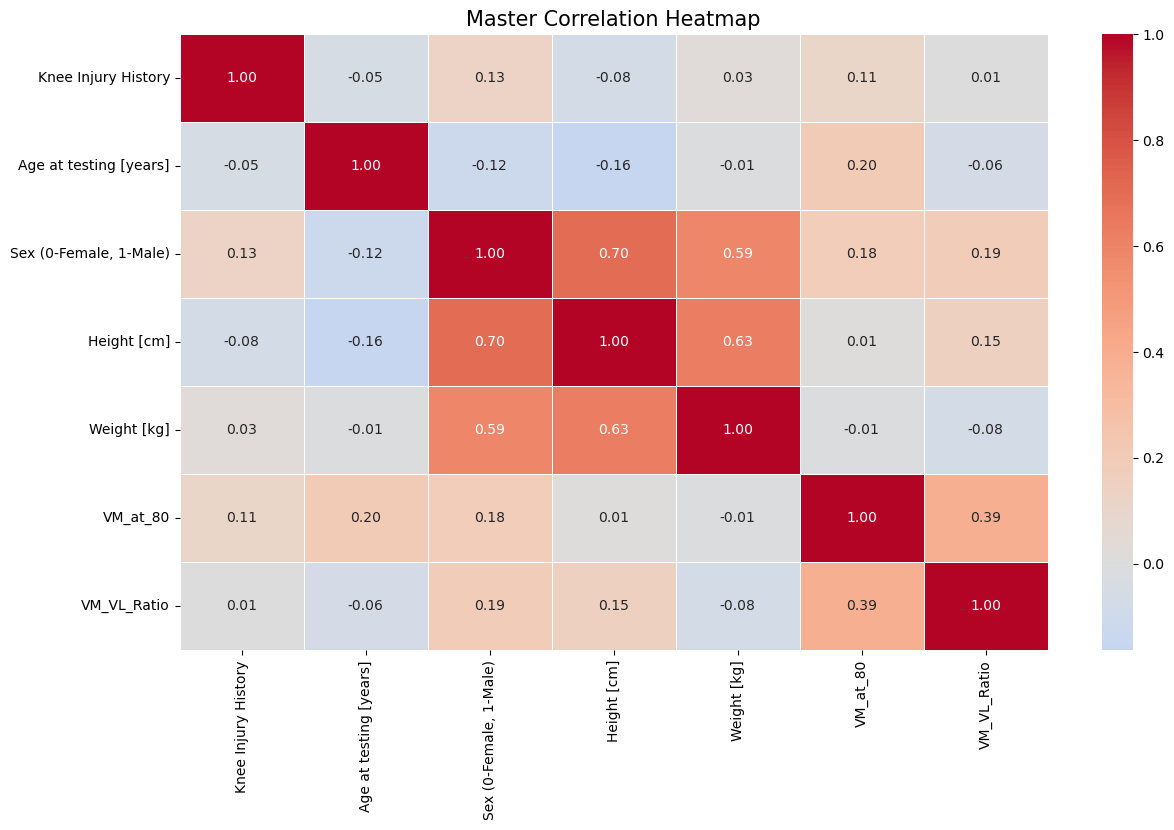

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 80포인트 지점 근육값 계산 (다시 한번 확실히!)
target_point = 80
m_idx = 1  # VM (내측광근)
vm_80_values = M_array[:, m_idx * 250 + target_point]

# 2. 상세 정보(df_info)와 근육값들을 하나의 표로 합치기
# df_info의 상위 122개 데이터와 우리가 만든 근육값들을 합칩니다.
df_final = df_info.iloc[:122].copy()
df_final['VM_at_80'] = vm_80_values
df_final['VM_Mean'] = df_individual['VM_Mean'].values
df_final['VL_Mean'] = df_individual['VL_Mean'].values
df_final['VM_VL_Ratio'] = df_final['VM_Mean'] / df_final['VL_Mean']

# 3. 히트맵에 넣을 변수 이름들 (스크린샷에 있는 이름 그대로!)
cols_for_corr = [
    'Knee Injury History', 
    'Age at testing [years]', 
    'Sex (0-Female, 1-Male)', 
    'Height [cm]', 
    'Weight [kg]', 
    'VM_at_80', 
    'VM_VL_Ratio'
]

# 4. 상관관계 계산 및 히트맵 그리기
plt.figure(figsize=(14, 8))
corr_matrix = df_final[cols_for_corr].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Master Correlation Heatmap", fontsize=15)
plt.show()

<Figure size 1000x700 with 0 Axes>

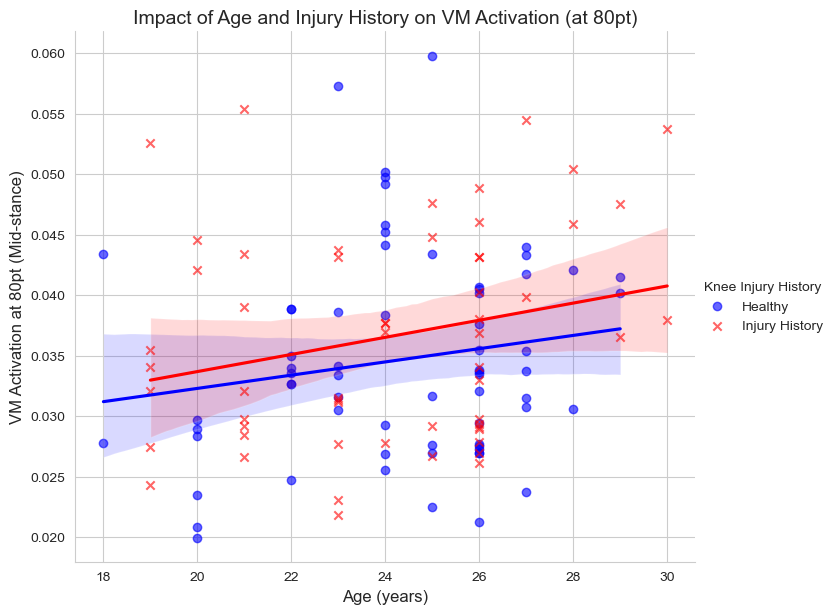

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 그래프 스타일 설정
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# 2. 산점도 + 추세선 그리기 (lmplot은 그룹별 추세선을 그려줍니다)
# x축: 나이, y축: 80pt VM값, hue: 부상이력
g = sns.lmplot(x='Age at testing [years]', y='VM_at_80', hue='Knee Injury History', 
               data=df_final, palette={0: 'blue', 1: 'red'}, 
               markers=["o", "x"], scatter_kws={'alpha':0.6}, height=6, aspect=1.2)

# 3. 그래프 꾸미기
plt.title("Impact of Age and Injury History on VM Activation (at 80pt)", fontsize=14)
plt.xlabel("Age (years)", fontsize=12)
plt.ylabel("VM Activation at 80pt (Mid-stance)", fontsize=12)

# 범례 이름 변경 (0: Healthy, 1: Injury)
new_labels = ['Healthy', 'Injury History']
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

plt.show()

In [ ]:
#"우리 데이터 분석 결과, 무릎 부상 이력이 있는 사람들은 모든 연령대에서 정상인보다 내측광근을 과도하게 사용(Over-activation)하며 걷고 있었습니다. 
#특히 나이가 들수록 이 경향은 심해지는데,
#이는 향후 2차적인 관절 손상으로 이어질 수 있으므로 장기적인 재활 관리가 필수적입니다."

In [ ]:
import os
print(os.path.abspath('2번째 파일.ipynb'))

In [24]:
df_final.to_csv('df_final.csv')